In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Salary Data.csv')
df.head()
x_train = df['YearsExperience'].values
y_train = df['Salary'].values

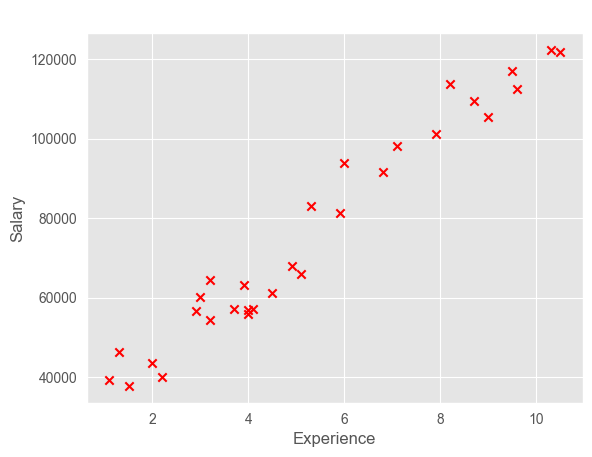

In [4]:
plt.style.use('ggplot')
plt.scatter(x_train, y_train, marker='x', c='red')
plt.title('Salary vs Experience')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.subplot()
plt.show()

In [5]:
def compute_model_output(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
    return f_wb

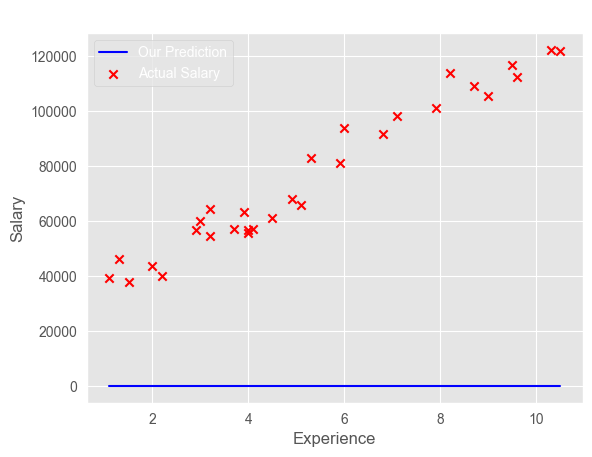

In [15]:
w, b = 0, 0
tmp_f_wb = compute_model_output(x_train, w, b,)
plt.plot(x_train, tmp_f_wb, c='b',label='Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='red', label='Actual Salary')
plt.legend()
plt.title('Salary vs Experience')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()

In [7]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = (f_wb- y[i]) ** 2
        cost_sum = cost_sum + cost

    total_cost = (1 / (2 * m)) * cost_sum
    return total_cost


In [8]:
def compute_gradient(x, y, w, b):

    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b

        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]

        dj_db += dj_db_i
        dj_dw += dj_dw_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [9]:
def gradient_descent(x, y, alpha, iterations):
    w, b = 0, 0
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i % 1000 == 0:
            print(f"Iteration: {i+1}, Cost: {compute_cost(x, y, w, b)}")
    print(f"w: {w}, b: {b}")
    return w, b

In [10]:
learning_rate = 0.01
iterations = 10000

w, b = gradient_descent(x_train, y_train, learning_rate, iterations)
tmp_f_wb = compute_model_output(x_train, w, b)


Iteration: 1, Cost: 1344612525.8413548
Iteration: 1001, Cost: 16523106.110673292
Iteration: 2001, Cost: 15648329.194311943
Iteration: 3001, Cost: 15635661.98387988
Iteration: 4001, Cost: 15635478.556291511
Iteration: 5001, Cost: 15635475.900167624
Iteration: 6001, Cost: 15635475.861705618
Iteration: 7001, Cost: 15635475.861148665
Iteration: 8001, Cost: 15635475.861140601
Iteration: 9001, Cost: 15635475.861140486
w: 9449.962323709777, b: 25792.20018347487


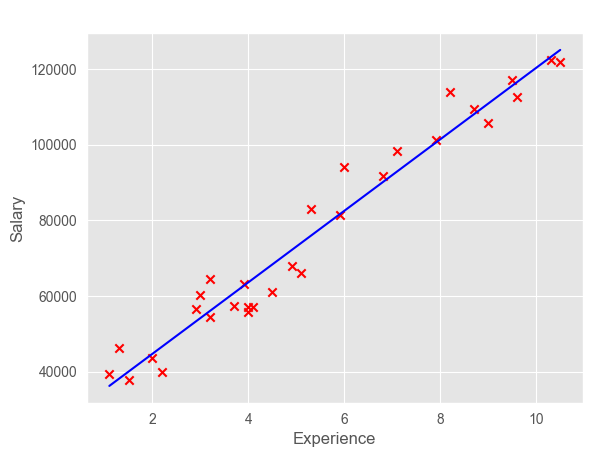

In [11]:
plt.plot(x_train, tmp_f_wb, c='b',label='Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='red')
plt.title('Salary vs Experience')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.show()